<a href="https://colab.research.google.com/github/DeemonDuck/upi-sentinel/blob/main/01_cnn_random_undersampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UPI Sentinel
Hybrid Deep Learning-Based Fraud Detection System

## 1. Importing Required Libraries


In [ ]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Imbalanced Learning
from imblearn.under_sampling import RandomUnderSampler

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Input


In [ ]:
df = pd.read_csv("data/paysim.csv")
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview and Integrity Check


In [ ]:
df.info()

missing_values = df.isnull().sum()
missing_values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


**Observations:**

- The dataset consists of 6.3 million transactions.
- No missing values were detected.
- Features include both numerical and categorical variables.
- The target column `isFraud` indicates fraudulent transactions.


### 2.2 Class Distribution Analysis


In [ ]:
fraud_distribution = df['isFraud'].value_counts()
fraud_distribution

if 1 in fraud_distribution:
    fraud_percentage = (fraud_distribution[1] / fraud_distribution.sum()) * 100
    fraud_percentage


**Observations:**

- The dataset is highly imbalanced.
- Fraudulent transactions represent only a very small percentage of the total transactions.
- This imbalance makes fraud detection a challenging classification problem.


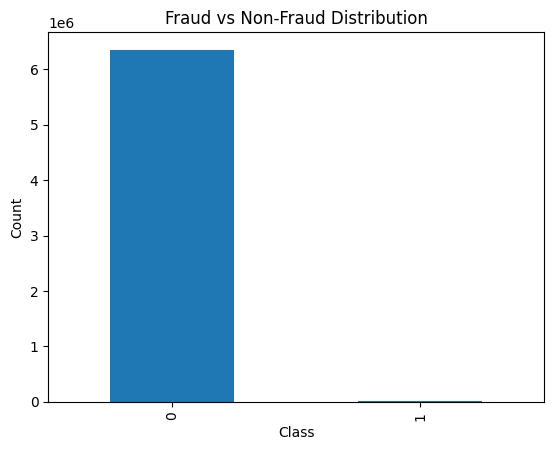

In [ ]:
fraud_distribution.plot(kind='bar')
plt.title("Fraud vs Non-Fraud Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


### 2.3 Fraud Distribution by Transaction Type


In [ ]:
# Total transactions by type
transaction_counts = df['type'].value_counts()
transaction_counts


,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


In [ ]:
# Count of fraudulent transactions by type
fraud_by_type = df.groupby('type')['isFraud'].sum()
fraud_by_type


,isFraud
type,
CASH_IN,0
CASH_OUT,4116
DEBIT,0
PAYMENT,0
TRANSFER,4097


In [ ]:
# Percentage of fraudulent transactions by type
fraud_by_type_percent = df.groupby('type')['isFraud'].mean() * 100
fraud_by_type_percent.sort_values(ascending=False)


,isFraud
type,
TRANSFER,0.768799
CASH_OUT,0.183955
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


**Observations:**

- Fraudulent transactions occur primarily in `TRANSFER` and `CASH_OUT` types.
- `PAYMENT`, `DEBIT`, and `CASH_IN` transactions show no fraudulent activity.
- `TRANSFER` transactions have the highest fraud percentage.


### 2.4 Transaction Amount Analysis (TRANSFER & CASH_OUT)


In [ ]:
# Filter relevant transaction types
relevant_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Statistics for fraudulent transactions
relevant_df[relevant_df['isFraud'] == 1]['amount'].describe()


,amount
count,8.213000e+03
mean,1.467967e+06
std,2.404253e+06
min,0.000000e+00
25%,1.270913e+05
50%,4.414234e+05
75%,1.517771e+06
max,1.000000e+07


In [ ]:
# Statistics for non-fraudulent transactions
relevant_df[relevant_df['isFraud'] == 0]['amount'].describe()


,amount
count,2.762196e+06
mean,3.141155e+05
std,8.771441e+05
min,1.000000e-02
25%,8.290823e+04
50%,1.710345e+05
75%,3.059942e+05
max,9.244552e+07


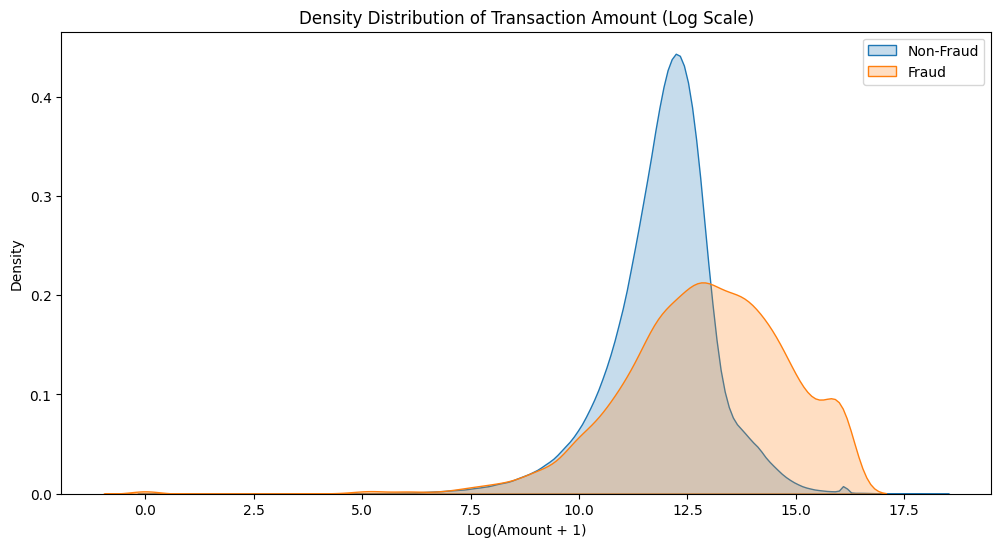

In [ ]:
plt.figure(figsize=(12, 6))

relevant_df['log_amount'] = np.log1p(relevant_df['amount'])

sns.kdeplot(
    data=relevant_df[relevant_df['isFraud'] == 0],
    x='log_amount',
    label='Non-Fraud',
    fill=True
)

sns.kdeplot(
    data=relevant_df[relevant_df['isFraud'] == 1],
    x='log_amount',
    label='Fraud',
    fill=True
)

plt.title('Density Distribution of Transaction Amount (Log Scale)')
plt.xlabel('Log(Amount + 1)')
plt.ylabel('Density')
plt.legend()
plt.show()


**Observations:**

- Fraudulent transactions tend to occur at specific higher transaction ranges.
- Log transformation helps visualize skewed transaction amounts.
- Transaction amount is a potentially informative feature for fraud detection.


### 2.5 Sender Balance Pattern Analysis


In [ ]:
# Filter relevant transaction types
relevant_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Create fraud-related balance patterns
relevant_df['account_emptied'] = (relevant_df['newbalanceOrig'] == 0).astype(int)
relevant_df['amount_matches_balance'] = (
    relevant_df['oldbalanceOrg'] == relevant_df['amount']
).astype(int)

# Analyze percentage of patterns by fraud class
pattern_analysis = (
    relevant_df.groupby('isFraud')[['account_emptied', 'amount_matches_balance']]
    .mean() * 100
)

pattern_analysis


,account_emptied,amount_matches_balance
isFraud,,
0,90.095091,0.000000
1,98.051869,97.820528


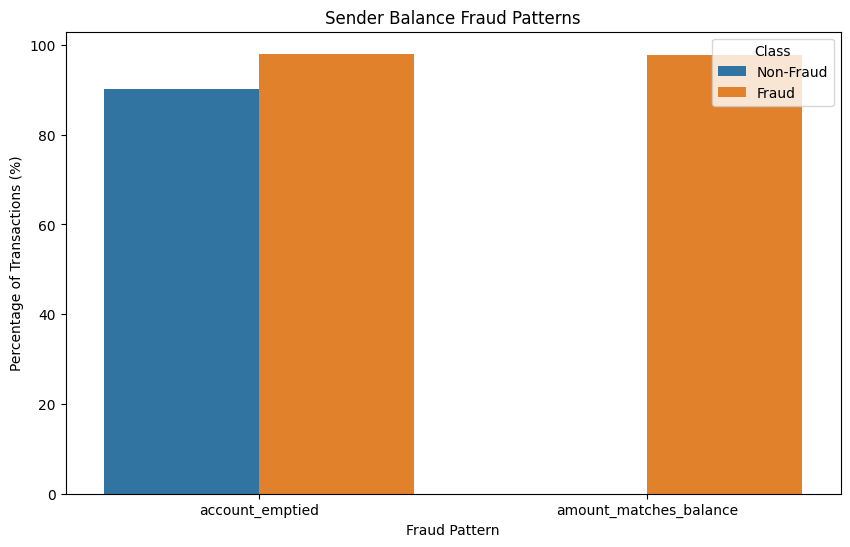

In [ ]:
#Plotting
plot_data = (
    pattern_analysis.reset_index()
    .melt('isFraud', var_name='Pattern', value_name='Percentage')
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_data,
    x='Pattern',
    y='Percentage',
    hue='isFraud'
)

plt.title('Sender Balance Fraud Patterns')
plt.xlabel('Fraud Pattern')
plt.ylabel('Percentage of Transactions (%)')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Non-Fraud', 'Fraud'], title='Class')

plt.show()


**Observation:**

- For non-fraudulent transactions (label 0), the percentages of `account_emptied` and `amount_matches_balance` are very low.
- For fraudulent transactions (label 1), both patterns occur significantly more frequently.
- A large proportion of fraud transactions result in the sender's account being completely emptied.
- Fraud transactions frequently match the sender's entire available balance.



**Conclusion:**

The analysis confirms several strong behavioral indicators of fraud:

1. Fraud occurs primarily in `TRANSFER` and `CASH_OUT` transaction types.
2. Fraudulent transactions follow a distinct transaction amount distribution.
3. Fraud transactions frequently empty the sender's account (`newbalanceOrig == 0`).
4. Fraud transactions often match the sender’s full available balance (`oldbalanceOrg == amount`).

These behavioral signals provide strong predictive features for the fraud detection model.


## 3. Data Preprocessing and Feature Engineering

Based on the insights obtained from the exploratory analysis, the dataset is refined and transformed to prepare it for model training.

The preprocessing steps include:

1. Filtering the dataset to retain only `TRANSFER` and `CASH_OUT` transaction types.
2. Creating engineered features:
   - `account_emptied`: Indicates whether the sender’s balance becomes zero after the transaction.
   - `amount_matches_balance`: Indicates whether the transaction amount equals the sender’s original balance.
3. Encoding the `type` column into numerical form for model compatibility.
4. Dropping irrelevant or redundant columns.


In [ ]:
# Filter relevant transaction types
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Create engineered fraud-related features
df_model['account_emptied'] = (df_model['newbalanceOrig'] == 0).astype(int)
df_model['amount_matches_balance'] = (
    df_model['oldbalanceOrg'] == df_model['amount']
).astype(int)

# Encode transaction type
df_model = pd.get_dummies(
    df_model,
    columns=['type'],
    drop_first=True
)

# Define feature columns
features = [
    'amount',
    'oldbalanceDest',
    'newbalanceDest',
    'account_emptied',
    'amount_matches_balance',
    'type_TRANSFER'
]

label = 'isFraud'

# Create final arrays
X_final = df_model[features].values.astype(np.float32)
y_final = df_model[label].values

print(f"Final X shape: {X_final.shape}")
print(f"Final y shape: {y_final.shape}")


Final X shape: (2770409, 6)
Final y shape: (2770409,)


## 4. Train-Test Split and Class Balancing

In [ ]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    stratify=y_final,
    random_state=42
)

print("Original Training Set Shape:", X_train.shape)
print("Fraud cases in y_train:", np.sum(y_train))

print("Original Testing Set Shape:", X_test.shape)
print("Fraud cases in y_test:", np.sum(y_test))

# Random undersampling (only on training data)
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print("\nBalanced Training Set Shape:", X_train_resampled.shape)
print("Fraud cases after balancing:", np.sum(y_train_resampled))
print("Non-Fraud cases after balancing:",
      len(y_train_resampled) - np.sum(y_train_resampled))


Original Training Set Shape: (2216327, 6)
Fraud cases in y_train: 6570
Original Testing Set Shape: (554082, 6)
Fraud cases in y_test: 1643

Balanced Training Set Shape: (13140, 6)
Fraud cases after balancing: 6570
Non-Fraud cases after balancing: 6570


**Observations:**

- The original dataset is highly imbalanced, with fraud cases representing a very small fraction of total transactions.
- Stratified splitting ensures that both training and testing sets maintain the same fraud distribution.
- Random undersampling balances the training data by reducing the number of non-fraud samples.
- The final training set contains an equal number of fraud and non-fraud samples, preventing model bias toward the majority class.


## 5. CNN Model Development and Evaluation


###5.1 Reshape Data for CNN

In [ ]:
n_features = X_train_resampled.shape[1]

X_train_cnn = X_train_resampled.reshape(-1, 1, n_features)
X_test_cnn = X_test.reshape(-1, 1, n_features)

print("Training shape:", X_train_cnn.shape)
print("Testing shape:", X_test_cnn.shape)


Training shape: (13140, 1, 6)
Testing shape: (554082, 1, 6)


### 5.2 Build CNN Model

In [ ]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(1, n_features)),
    Conv1D(filters=32, kernel_size=1, activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


###5.3 Compile

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 32)          │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,625 (14.16 KB)

 Trainable params: 3,625 (14.16 KB)

 Non-trainable params: 0 (0.00 B)

###5.4 Train

In [ ]:
history = model.fit(
    X_train_cnn,
    y_train_resampled,
    epochs=10,
    batch_size=64,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)


Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - accuracy: 0.6915 - loss: 59935.5664 - val_accuracy: 0.7849 - val_loss: 4109.6665
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.7013 - loss: 9267.9092 - val_accuracy: 0.7728 - val_loss: 905.4434
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.7182 - loss: 813.2911 - val_accuracy: 0.7690 - val_loss: 233.0323
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.7162 - loss: 327.1144 - val_accuracy: 0.7762 - val_loss: 122.5033
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.7208 - loss: 142.3151 - val_accuracy: 0.5333 - val_loss: 168.7881
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.7027 - loss: 156.2013 - val_accuracy: 0.7446 - val_loss: 99.9591
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.7203 - loss: 67.6691 - val_accuracy: 0.2681 - val_loss: 221.3260
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - ac

###5.5 Evaluate

In [ ]:
y_pred_proba = model.predict(X_test_cnn)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Non-Fraud', 'Fraud']
))


17316/17316 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.65      0.79    552439
       Fraud       0.01      0.82      0.01      1643

    accuracy                           0.65    554082
   macro avg       0.50      0.73      0.40    554082
weighted avg       1.00      0.65      0.78    554082



### Model Performance Analysis

- The model achieves 65% overall accuracy.
- Fraud recall is high (82%), meaning the model successfully detects the majority of fraudulent transactions.
- However, fraud precision is extremely low (1%), indicating a large number of false positives.
- The drop in non-fraud recall (65%) suggests that many legitimate transactions are being incorrectly flagged as fraud.

This behavior reflects a strong bias toward detecting fraud at the expense of precision. While high recall is desirable in fraud detection, excessive false positives can negatively impact user experience and system reliability.


### 5.6 Confusion Matrix Analysis


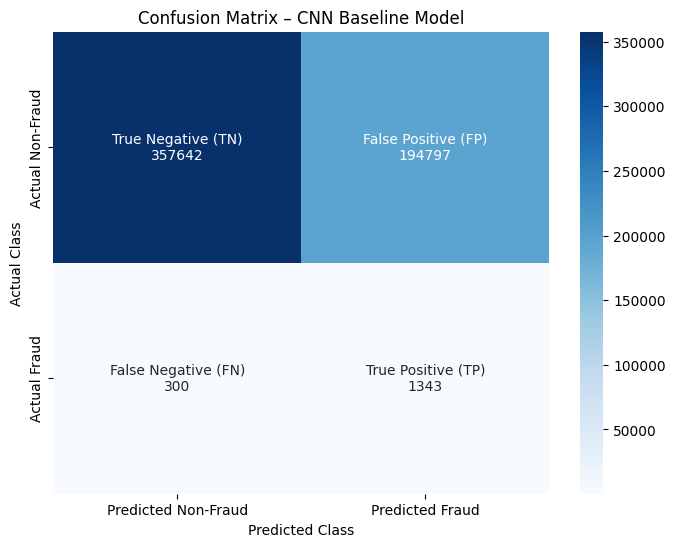

In [ ]:
cm = confusion_matrix(y_test, y_pred)

labels = ['True Negative (TN)', 'False Positive (FP)',
          'False Negative (FN)', 'True Positive (TP)']

counts = cm.flatten()
box_labels = [f"{label}\n{count}" for label, count in zip(labels, counts)]
box_labels = np.asarray(box_labels).reshape(2, 2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=box_labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
    yticklabels=['Actual Non-Fraud', 'Actual Fraud']
)

plt.title('Confusion Matrix – CNN Baseline Model')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


### Confusion Matrix Analysis

- True Positives (Fraud correctly detected): 1,343
- False Negatives (Fraud missed): 300
- False Positives (Legitimate transactions flagged as fraud): 194,797

The model achieves high fraud recall (~82%), meaning most fraudulent transactions are successfully detected.

However, the number of false positives is extremely high, resulting in very low precision. A large number of legitimate transactions are incorrectly classified as fraud.

This behavior reflects a recall-heavy model, where the objective of minimizing missed fraud cases comes at the cost of significantly increased false alarms.
